# Diabetes Multi-Class Classification & Clustering
**Dataset:** Mendeley Diabetes Dataset — 3 Classes: N (Non-Diabetic), P (Pre-Diabetic), Y (Diabetic)  
**Goal:** Build classification and clustering models. Compare, evaluate, and interpret results.



In [8]:
import pandas as pd

df = pd.read_csv('../data/raw/dataset.csv')   # adjust filename as needed

print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 14)


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [9]:
print(' Data Types')
print(df.dtypes)
print('\n Null Values ')
print(df.isnull().sum())
print('\n Class Distribution ')
print(df['CLASS'].value_counts())
print(f"\nClass proportions:\n{df['CLASS'].value_counts(normalize=True).round(3)}")

 Data Types
ID             int64
No_Pation      int64
Gender        object
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS         object
dtype: object

 Null Values 
ID           0
No_Pation    0
Gender       0
AGE          0
Urea         0
Cr           0
HbA1c        0
Chol         0
TG           0
HDL          0
LDL          0
VLDL         0
BMI          0
CLASS        0
dtype: int64

 Class Distribution 
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64

Class proportions:
CLASS
Y     0.840
N     0.102
P     0.053
Y     0.004
N     0.001
Name: proportion, dtype: float64


In [10]:
df.describe().round(2)

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,340.50,270551.41,53.53,5.12,68.94,8.28,4.86,2.35,1.20,2.61,1.85,29.58
std,240.40,3380757.82,8.80,2.94,59.98,2.53,1.30,1.40,0.66,1.12,3.66,4.96
min,1.00,123.00,20.00,0.50,6.00,0.90,0.00,0.30,0.20,0.30,0.10,19.00
25%,125.75,24063.75,51.00,3.70,48.00,6.50,4.00,1.50,0.90,1.80,0.70,26.00
50%,300.50,34395.50,55.00,4.60,60.00,8.00,4.80,2.00,1.10,2.50,0.90,30.00
75%,550.25,45384.25,59.00,5.70,73.00,10.20,5.60,2.90,1.30,3.30,1.50,33.00
max,800.00,75435657.00,79.00,38.90,800.00,16.00,10.30,13.80,9.90,9.90,35.00,47.75


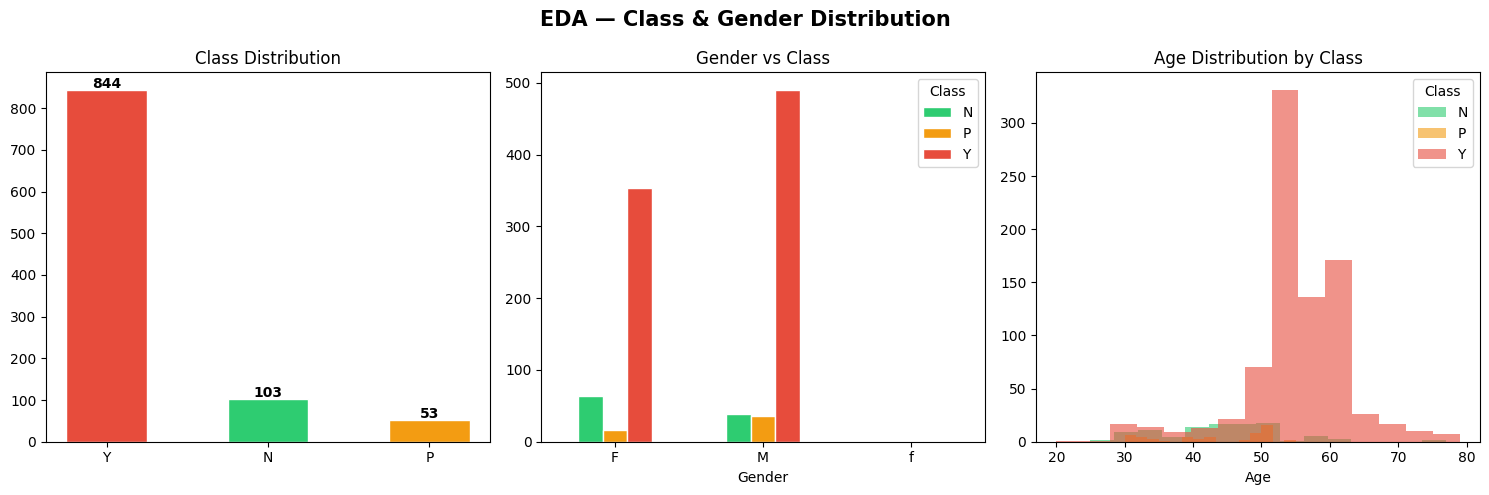

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

COLORS = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}
df['CLASS'] = df['CLASS'].str.strip()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA — Class & Gender Distribution', fontsize=15, fontweight='bold')

cls_counts = df['CLASS'].value_counts()
axes[0].bar(cls_counts.index, cls_counts.values,
            color=[COLORS[c] for c in cls_counts.index], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution')
for i, (k, v) in enumerate(cls_counts.items()):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

gen_cls = df.groupby(['Gender','CLASS']).size().unstack()
gen_cls.plot(kind='bar', ax=axes[1],
             color=[COLORS[c] for c in gen_cls.columns], edgecolor='white', rot=0)
axes[1].set_title('Gender vs Class'); axes[1].legend(title='Class')

for cls, grp in df.groupby('CLASS'):
    axes[2].hist(grp['AGE'], bins=15, alpha=0.6, label=cls, color=COLORS[cls])
axes[2].set_title('Age Distribution by Class')
axes[2].set_xlabel('Age'); axes[2].legend(title='Class')

plt.tight_layout()
plt.show()